# 1. SLA Breach Distribution

## Business Question

Is the target variable balanced?

## Objective

Understand the distribution of SLA outcomes and assess whether class imbalance handling will be required during model development.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
visual_df=pd.read_csv('../../data/raw/incident_event_log.csv')

In [3]:
PLOTS_DIR = "../../artifacts/plots/"

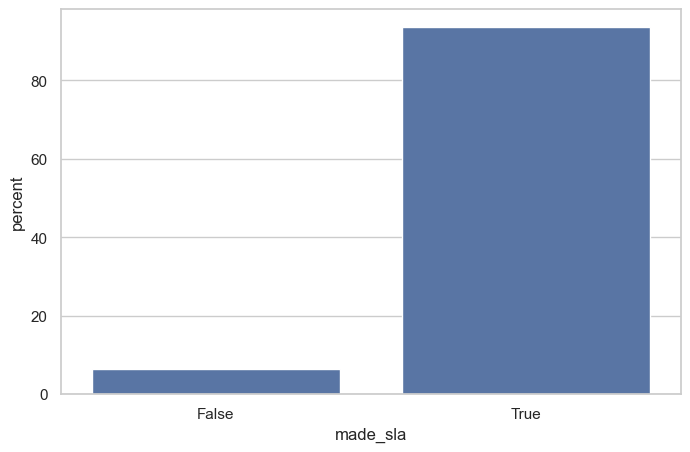

In [4]:
fig, ax = plt.subplots(figsize=(8,5))

sns.countplot(
    data=visual_df,
    x='made_sla',
    stat='percent',
    ax=ax
)

fig.savefig(
    "../../artifacts/plots/01_sla_distribution_count.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

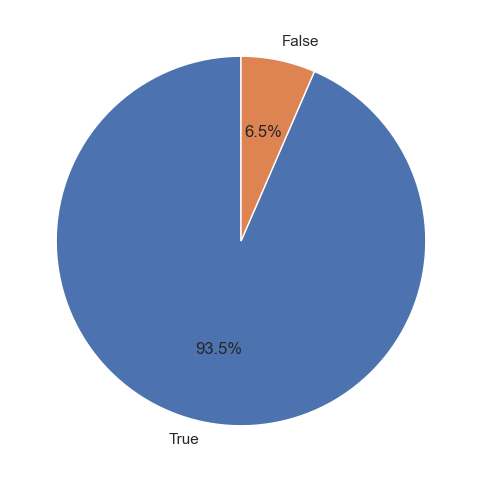

In [5]:
counts = visual_df['made_sla'].value_counts()

fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

fig.savefig(
    "../../artifacts/plots/01_sla_distribution_pie.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The target variable is highly imbalanced.

93.5% of incidents met SLA commitments.

Only 6.5% resulted in SLA breaches.

This indicates that SLA breach prediction is an imbalanced classification problem.

During model development, evaluation metrics such as Recall, Precision, F1-Score, and ROC-AUC will be prioritized over Accuracy. Class imbalance handling techniques such as class weighting and SMOTE will also be evaluated.

In [6]:
%store -r category_details
visual_category_details=(category_details[category_details['Total_incidents']>=500]).sort_values(by='Breach_percentage',ascending=False).head(10)

In [7]:
visual_category_details

,category,Total_incidents,Breaches,Breach_percentage
36,Category 45,3619,465,12.848853
47,Category 55,801,87,10.861423
37,Category 46,13324,1262,9.471630
25,Category 34,3946,340,8.616320
53,Category 61,5168,442,8.552632
35,Category 44,1798,152,8.453838
8,Category 19,1592,130,8.165829
31,Category 40,3760,267,7.101064
18,Category 28,2256,160,7.092199
34,Category 43,858,59,6.876457


In [8]:
visual_category_details.columns

Index(['category', 'Total_incidents', 'Breaches', 'Breach_percentage'], dtype='str')

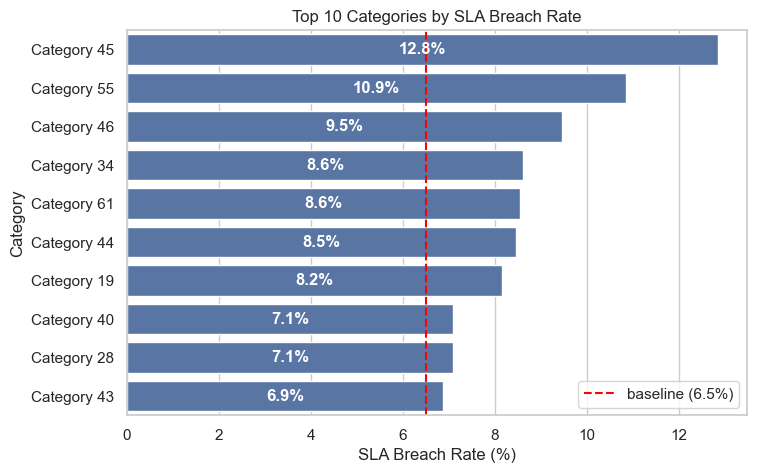

In [9]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    data=visual_category_details,
    x='Breach_percentage',
    y='category',
    ax=ax
)
ax.axvline(x=6.5,color='red',linestyle='--',linewidth=1.5,label="baseline (6.5%)")
for container in ax.containers:
    ax.bar_label(container=container,fmt='%.1f%%',label_type='center',color='white',weight='bold')


plt.xlabel("SLA Breach Rate (%)")
plt.ylabel("Category")
plt.title("Top 10 Categories by SLA Breach Rate")

plt.legend(loc='lower right')

fig.savefig(
    "../../artifacts/plots/02_category_risk_rate.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### Key Findings

- Category 45 has the highest SLA breach rate at 12.8%.
- Category 55 has a breach rate of 10.9%.
- Category 46 has a breach rate of 9.5%.
- All top ten categories exceed the overall breach baseline of 6.5%.

### Business Interpretation

SLA performance varies significantly across service categories.

Incidents belonging to Category 45 are almost twice as likely to breach SLA commitments compared with the average incident.

This indicates that category is an important operational risk indicator and should be retained as a candidate feature for machine learning modeling.

The findings also suggest that operational improvement initiatives could be prioritized for high-risk categories to reduce SLA violations.

In [10]:
%store -r subcategory_details
visual_subcategory_details=(subcategory_details[subcategory_details['Total_incidents']>=500]).sort_values(by='Breach_percentage',ascending=False).head(10)

In [11]:
visual_subcategory_details

,subcategory,Total_incidents,Breaches,Breach_percentage
119,Subcategory 220,702,118,16.81
48,Subcategory 150,1659,244,14.71
130,Subcategory 231,857,122,14.24
245,Subcategory 88,624,74,11.86
101,Subcategory 200,792,92,11.62
198,Subcategory 31,973,110,11.31
154,Subcategory 255,514,58,11.28
250,Subcategory 94,720,74,10.28
36,Subcategory 134,675,68,10.07
58,Subcategory 16,772,76,9.84


In [12]:
visual_subcategory_details.info()

<class 'pandas.DataFrame'>
Index: 10 entries, 119 to 58
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subcategory        10 non-null     str    
 1   Total_incidents    10 non-null     int64  
 2   Breaches           10 non-null     int64  
 3   Breach_percentage  10 non-null     float64
dtypes: float64(1), int64(2), str(1)
memory usage: 400.0 bytes


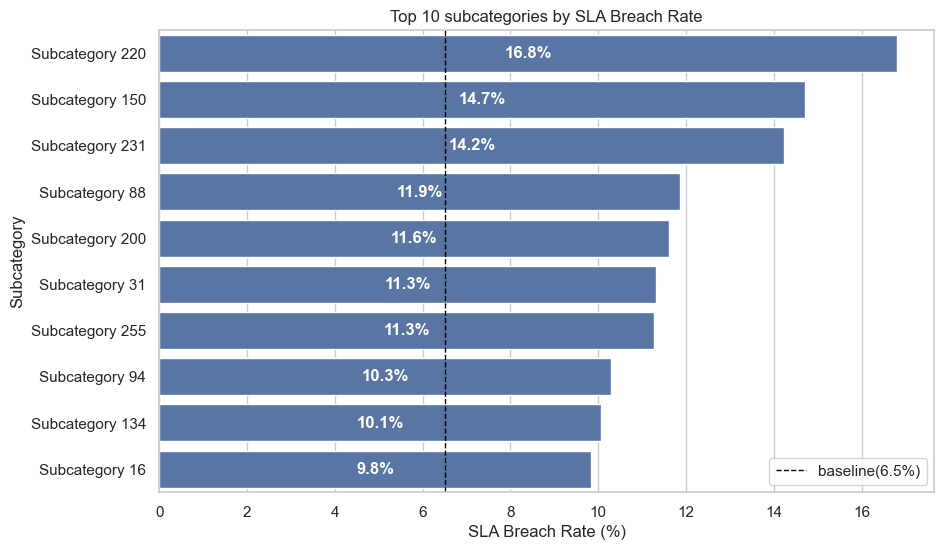

In [13]:
fig,ax=plt.subplots(figsize=(10,6))

sns.barplot(data=visual_subcategory_details,
            x='Breach_percentage',
            y='subcategory',
            ax=ax)

ax.axvline(x=6.5,color='black',linewidth='1.0',linestyle='--',label='baseline(6.5%)')
for container in ax.containers:
    ax.bar_label(container=container,label_type='center',fmt='%.1f%%',color='white',weight='bold')

plt.xlabel("SLA Breach Rate (%)")
plt.ylabel("Subcategory")
plt.title("Top 10 subcategories by SLA Breach Rate")

plt.legend(loc='lower right')


plt.savefig(
    "../../artifacts/plots/03_subcategory_risk_rate.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


### Key Findings

* Subcategory 220 has the highest SLA breach rate at 16.8%.
* Subcategory 150 has a breach rate of 14.7%.
* Subcategory 231 has a breach rate of 14.2%.
* All top ten subcategories exceed the overall dataset breach baseline of 6.5%.
* The highest-risk subcategory (Subcategory 220) has a breach rate that is more than 2.5 times the overall breach rate.

### Business Interpretation

The probability of SLA breach varies significantly across service subcategories. Compared to the category-level analysis, subcategories provide a more detailed view of operational risk and help identify specific service areas that consistently experience SLA violations.

Subcategory 220, Subcategory 150, and Subcategory 231 represent the highest-risk service areas and may require deeper operational investigation, additional support resources, improved incident routing, or process optimization.

The findings suggest that incident subcategory is a strong indicator of SLA performance and can be used to identify high-risk incidents immediately after ticket creation.

### Modeling Implication

The subcategory feature demonstrates stronger separation of SLA breach risk than the category feature. Since multiple subcategories show breach rates significantly above the organizational baseline, subcategory should be retained as a high-priority feature for machine learning modeling.

Based on the EDA results, subcategory is expected to be one of the most influential predictors in the SLA breach prediction model and will be further validated during feature importance and SHAP analysis.


In [14]:
%store -r u_symptom_details
visual_u_symptom_details=(u_symptom_details[u_symptom_details['Total_incidents']>=500]).sort_values(by='Breach_rate',ascending=False).head(10).reset_index()

In [15]:
visual_u_symptom_details

,u_symptom,Total_incidents,Breaches,Breach_rate
0,Symptom 208,1112,117,10.52
1,Symptom 120,930,84,9.03
2,Symptom 4,2532,225,8.89
3,Symptom 6,702,62,8.83
4,Symptom 458,849,71,8.36
5,Symptom 592,562,46,8.19
6,Symptom 102,880,72,8.18
7,Symptom 571,1771,144,8.13
8,?,32964,2587,7.85
9,Symptom 470,1051,79,7.52


In [16]:
visual_u_symptom_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   u_symptom        10 non-null     str    
 1   Total_incidents  10 non-null     int64  
 2   Breaches         10 non-null     int64  
 3   Breach_rate      10 non-null     float64
dtypes: float64(1), int64(2), str(1)
memory usage: 452.0 bytes


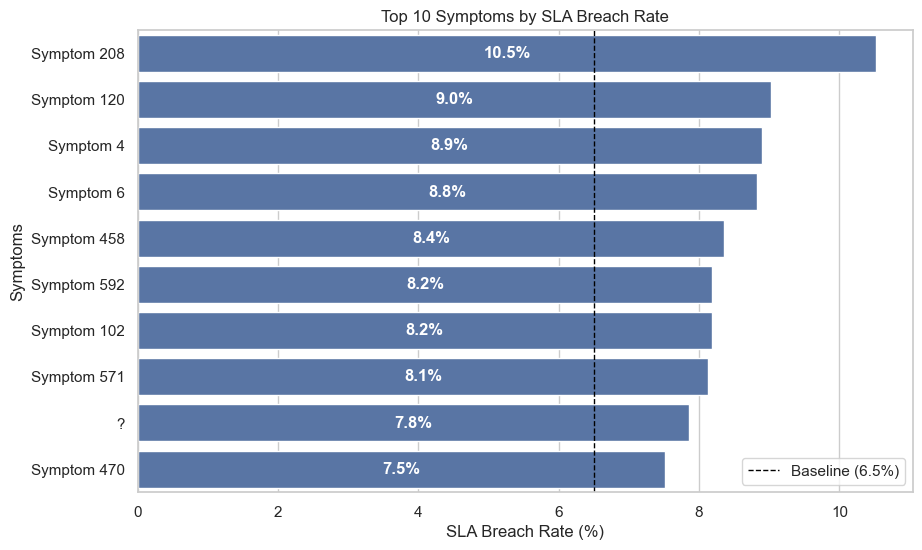

In [17]:
fig,ax=plt.subplots(figsize=(10,6))

sns.barplot(data=visual_u_symptom_details,
            x='Breach_rate',
            y='u_symptom',
            ax=ax)
ax.axvline(x=6.5,linewidth='1.0',linestyle="--",color='black',label='Baseline (6.5%)')
for container in ax.containers:
    ax.bar_label(container=container,fmt='%.1f%%',label_type='center',color='white',weight='bold')

plt.xlabel("SLA Breach Rate (%)")
plt.ylabel("Symptoms")
plt.title("Top 10 Symptoms by SLA Breach Rate")

plt.legend(loc='lower right')

plt.savefig(
    "../../artifacts/plots/04_symptom_risk_rate.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Findings

* Symptom 208 has the highest SLA breach rate at 10.5%.
* Symptom 120 has a breach rate of 9.0%.
* Symptom 4 has a breach rate of 8.9%.
* All top ten symptoms exceed the overall dataset breach baseline of 6.5%.
* The Unknown Symptom (?) group has a breach rate of 7.8%, which is higher than the overall breach rate.

### Business Interpretation

The likelihood of SLA breach varies significantly across incident symptoms. Certain symptoms consistently exhibit higher breach rates and may represent recurring operational issues, complex service failures, or incident types that require specialized expertise.

The presence of the Unknown Symptom (?) category among the top-risk groups is particularly important. Incidents created without a clearly identified symptom are more likely to breach SLA commitments than the average incident. This suggests that incomplete incident information may negatively impact triage, routing, and resolution efficiency.

Support teams may benefit from improving incident classification quality and ensuring that symptoms are accurately captured during ticket creation.

### Modeling Implication

The symptom feature demonstrates strong predictive potential and should be retained as a high-priority feature for machine learning modeling.

Additionally, the Unknown Symptom category should not be removed or treated as missing data. The EDA indicates that unknown values contain meaningful business information and may contribute to SLA breach prediction.

Based on the observed separation of breach rates, symptom is expected to be one of the most influential features in the final model and will be further validated through feature importance and SHAP analysis.


In [18]:
%store -r location_details
visual_location_details=(location_details[location_details['Total_incidents']>=500]).sort_values(by='Breach_rate',ascending=False).head(10)

In [19]:
visual_location_details

,location,Total_incidents,Breaches,Breach_rate
171,Location 42,666,54,8.11
166,Location 38,556,43,7.73
12,Location 111,1530,116,7.58
105,Location 204,31690,2250,7.10
36,Location 135,1094,77,7.04
44,Location 143,19245,1351,7.02
185,Location 56,907,63,6.95
170,Location 41,630,43,6.83
221,Location 96,1203,82,6.82
184,Location 55,1467,99,6.75


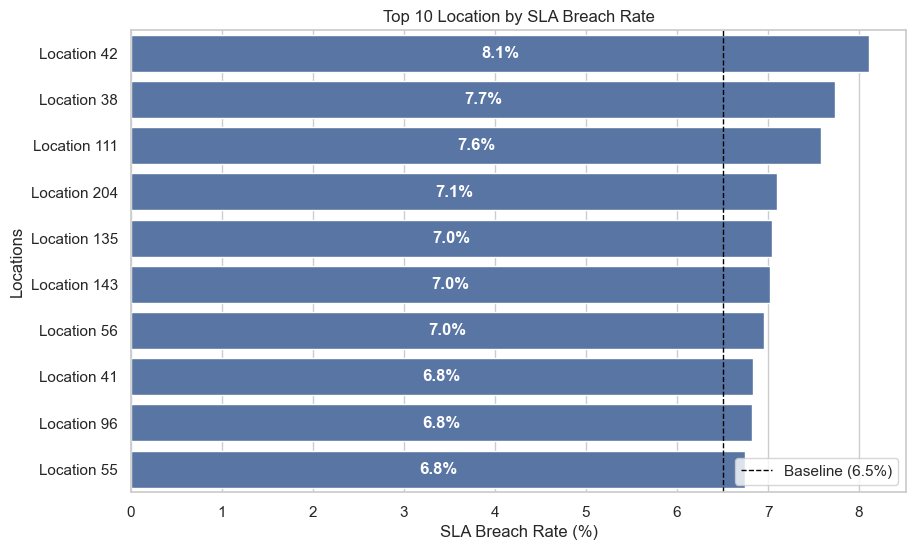

In [20]:
fig,ax=plt.subplots(figsize=(10,6))

sns.barplot(data=visual_location_details,
            x='Breach_rate',
            y='location',
            ax=ax)
ax.axvline(x=6.5,linewidth='1.0',linestyle="--",color='black',label='Baseline (6.5%)')
for container in ax.containers:
    ax.bar_label(container=container,fmt='%.1f%%',label_type='center',color='white',weight='bold')

plt.xlabel("SLA Breach Rate (%)")
plt.ylabel("Locations")
plt.title("Top 10 Location by SLA Breach Rate")

plt.legend(loc='lower right')

plt.savefig(
    "../../artifacts/plots/05_location_risk_rate.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Findings

* Location 42 has the highest SLA breach rate at 8.1%.
* Location 38 has a breach rate of 7.7%.
* Location 111 has a breach rate of 7.6%.
* All top ten locations exceed the overall dataset breach baseline of 6.5%.
* Location 204 appears in the high-risk list and was also identified earlier as one of the locations generating the highest number of breaches.

### Business Interpretation

SLA performance varies across operational locations. Certain locations consistently experience higher breach rates than the organizational average, indicating possible differences in infrastructure stability, support coverage, workload distribution, incident complexity, or operational processes.

While Location 42 exhibits the highest breach rate, Location 204 deserves special attention because it combines a higher-than-average breach rate with a very large incident volume. This means Location 204 contributes a significant number of total SLA breaches and may offer the greatest opportunity for operational improvement.

These findings suggest that location-specific operational factors may influence incident resolution performance and should be investigated further.

### Modeling Implication

The location feature demonstrates predictive value and should be retained for machine learning modeling.

Location may capture underlying operational characteristics that are not directly represented by other features. Although the breach rate differences are smaller than those observed for subcategory and symptom, location still provides useful information for SLA breach prediction and may contribute to overall model performance.

Based on the EDA results, location is expected to have moderate predictive importance and will be validated through feature importance analysis and SHAP explanations.


In [21]:
%store -r contact_details
visual_contact_details=(contact_details[contact_details['Total_incidents']>=200]).sort_values(by='Breach_rate',ascending=False).head(10).reset_index()

In [22]:
visual_contact_details

,contact_type,Total_incidents,Breaches,Breach_rate
0,Email,220,39,17.73
1,Self service,995,70,7.04
2,Phone,140462,9106,6.48


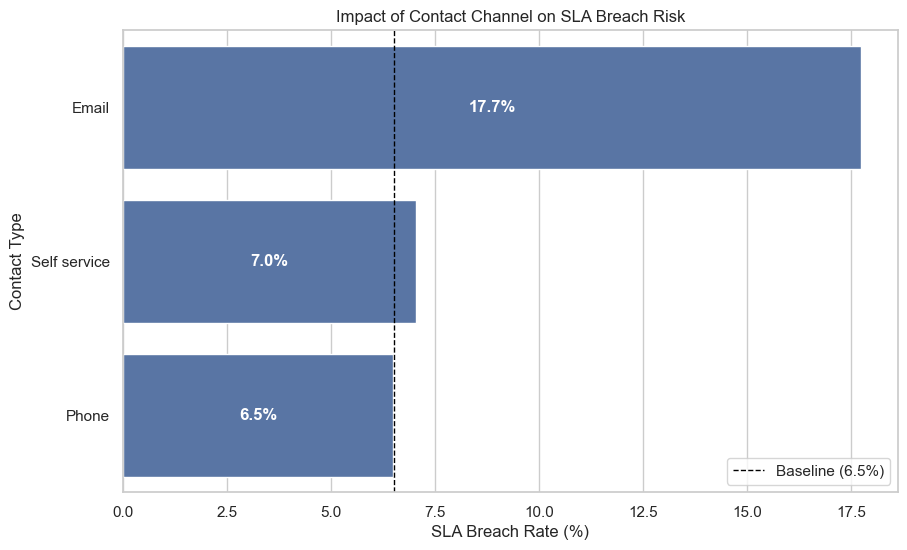

In [23]:
fig,ax=plt.subplots(figsize=(10,6))

sns.barplot(data=visual_contact_details,
            x='Breach_rate',
            y='contact_type',
            ax=ax)
ax.axvline(x=6.5,linewidth='1.0',linestyle="--",color='black',label='Baseline (6.5%)')
for container in ax.containers:
    ax.bar_label(container=container,fmt='%.1f%%',label_type='center',color='white',weight='bold')

plt.xlabel("SLA Breach Rate (%)")
plt.ylabel("Contact Type")
plt.title("Impact of Contact Channel on SLA Breach Risk")

plt.legend(loc='lower right')

plt.savefig(
    "../../artifacts/plots/06_contact_risk_rate.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Findings

* Email has the highest SLA breach rate at 17.7%.
* Self Service has a breach rate of 7.0%.
* Phone has a breach rate of 6.5%, which is approximately equal to the overall dataset baseline.
* Incidents reported through Email are nearly three times more likely to breach SLA commitments compared to the average incident.

### Business Interpretation

The incident reporting channel appears to have a significant impact on SLA performance.

Email-based incidents exhibit a substantially higher breach rate than incidents reported through Phone or Self Service channels. This may indicate delays in triage, incomplete incident information, slower routing, or lower prioritization of email-generated tickets.

Although Phone incidents generate the largest incident volume, their breach rate remains close to the organizational average. In contrast, Email incidents represent a smaller volume but a much higher operational risk.

These findings suggest that the incident intake process may influence downstream SLA performance and should be reviewed from an operational perspective.

### Modeling Implication

The contact_type feature demonstrates strong predictive value and should be retained for machine learning modeling.

The large separation between Email and other reporting channels suggests that contact_type may be an important predictor of SLA breach risk. The feature may help identify high-risk incidents immediately at ticket creation time.

Feature importance analysis and SHAP explanations will be used to validate the contribution of contact_type in the final prediction model.


In [24]:
%store -r opened_at_details_hour
visual_opened_at_details_hour = (
    opened_at_details_hour[
        opened_at_details_hour['Total_incidents'] >= 500
    ]
    .sort_values('Hour')
).reset_index()

In [25]:
visual_opened_at_details_hour.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Hour             24 non-null     int32  
 1   Total_incidents  24 non-null     int64  
 2   Breaches         24 non-null     int64  
 3   Breach_rate      24 non-null     float64
dtypes: float64(1), int32(1), int64(2)
memory usage: 804.0 bytes


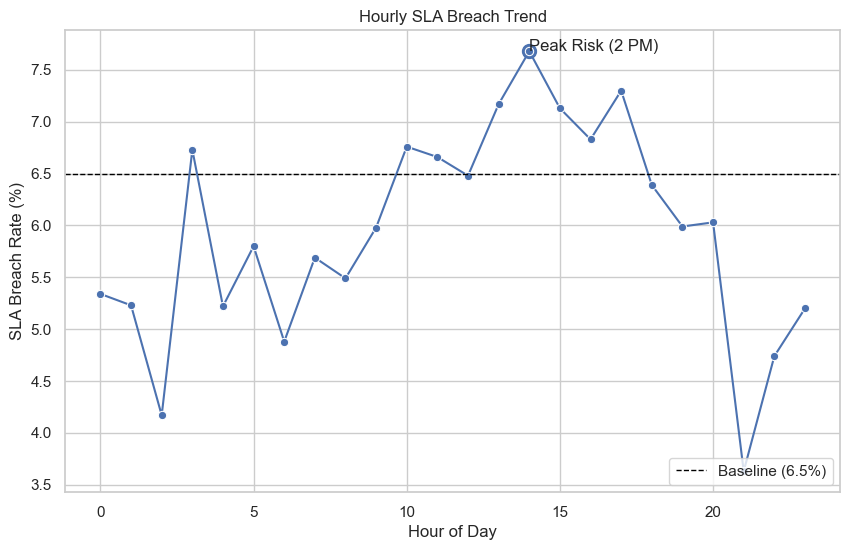

In [26]:
fig,ax=plt.subplots(figsize=(10,6))

sns.lineplot(
    data=visual_opened_at_details_hour,
    x='Hour',
    y='Breach_rate',
    marker='o',
    ax=ax
)
ax.scatter(
    x=[14],
    y=[7.68],
    s=100
)

ax.annotate(
    "Peak Risk (2 PM)",
    xy=(14, 7.68)
)
ax.axhline(y=6.5,linewidth='1.0',linestyle="--",color='black',label='Baseline (6.5%)')
for container in ax.containers:
    ax.bar_label(container=container,fmt='%.1f%%',label_type='center',color='white',weight='bold')

plt.xlabel("Hour of Day")
plt.ylabel("SLA Breach Rate (%)")
plt.title("Hourly SLA Breach Trend")

plt.legend(loc='lower right')

plt.savefig(
    "../../artifacts/plots/07_hourly_breach_trend.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Key Findings
SLA breach rates vary throughout the day.
The highest breach rate occurs at 2 PM (7.68%).
Afternoon hours between 1 PM and 5 PM consistently exceed the organizational baseline of 6.5%.
Late evening and early morning hours generally exhibit lower breach rates.
The lowest breach rate is observed at 9 PM (3.63%).
Business Interpretation

The timing of incident creation appears to influence SLA performance.

Incidents opened during afternoon business hours are more likely to breach SLA commitments than incidents opened during other periods. This may indicate higher ticket volumes, resource constraints, workload concentration, or operational bottlenecks during peak support hours.

The observed pattern suggests that workload balancing, staffing optimization, and proactive monitoring during afternoon hours may help reduce SLA violations.

Modeling Implication

The Hour feature contains meaningful temporal information and should be retained for machine learning modeling.

Time-of-day patterns can help identify elevated SLA breach risk immediately when an incident is created and may improve predictive model performance.

In [27]:
%store -r opened_at_details_day_of_week
visual_opened_at_details_day_of_week = (
    opened_at_details_day_of_week[
        opened_at_details_day_of_week['Total_incidents'] >= 500
    ]
    .sort_values('Day_of_week')
).reset_index()

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

visual_opened_at_details_day_of_week['Day_of_week'] = pd.Categorical(
    visual_opened_at_details_day_of_week['Day_of_week'],
    categories=day_order,
    ordered=True
)

visual_opened_at_details_day_of_week = (
    visual_opened_at_details_day_of_week
    .sort_values('Day_of_week')
)



In [28]:
visual_opened_at_details_day_of_week

,Day_of_week,Total_incidents,Breaches,Breach_rate
1,Monday,33744,2128,6.31
5,Tuesday,28598,1940,6.78
6,Wednesday,28104,1988,7.07
4,Thursday,23472,1566,6.67
0,Friday,21695,1301,6.00
2,Saturday,3237,135,4.17
3,Sunday,2862,157,5.49


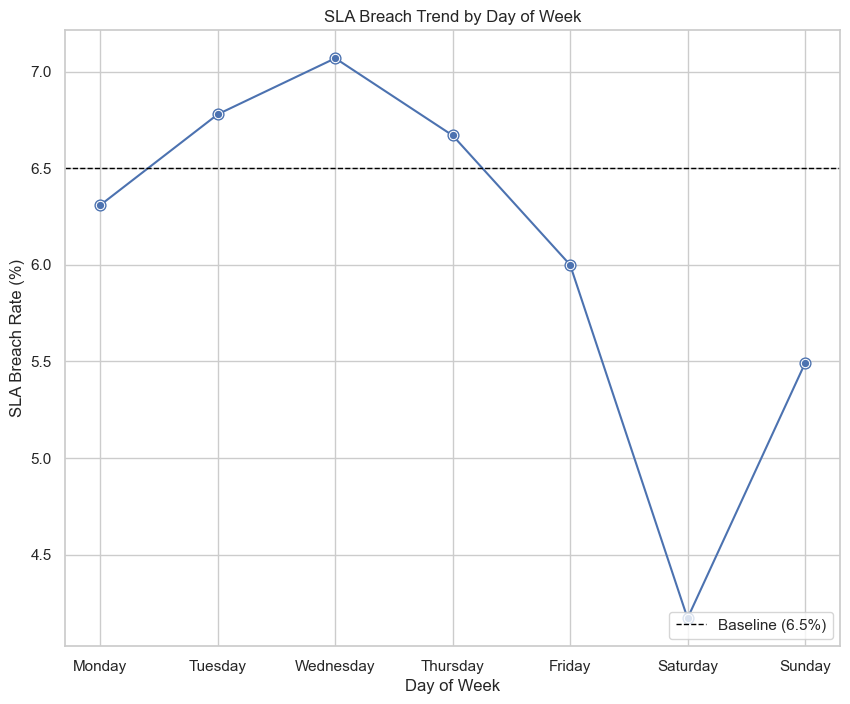

In [29]:
fig,ax=plt.subplots(figsize=(10,8))

sns.lineplot(
    data=visual_opened_at_details_day_of_week,
    x='Day_of_week',
    y='Breach_rate',
    marker='o',
    ax=ax
)
ax.scatter(
    visual_opened_at_details_day_of_week['Day_of_week'],
    visual_opened_at_details_day_of_week['Breach_rate'],
    s=60
)


ax.axhline(y=6.5,linewidth='1.0',linestyle="--",color='black',label='Baseline (6.5%)')
# for container in ax.containers:
    # ax.bar_label(container=container,fmt='%.1f%%',label_type='center',color='white',weight='bold')

plt.xlabel("Day of Week")
plt.ylabel("SLA Breach Rate (%)")
plt.title("SLA Breach Trend by Day of Week")

plt.legend(loc='lower right')

plt.savefig(
    "../../artifacts/plots/08_day_of_week_breach_trend.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Findings

- Wednesday has the highest SLA breach rate at 7.07%.
- Tuesday and Thursday also exceed the organizational baseline of 6.5%.
- Weekend incidents exhibit significantly lower breach rates.
- Saturday has the lowest breach rate at 4.17%.

### Business Interpretation

SLA breach risk follows a weekly operational pattern. Midweek incidents (Tuesday–Thursday) are more likely to breach SLA commitments than incidents opened on weekends.

This pattern may reflect increased workload, ticket volume, operational complexity, or resource constraints during core business days.

The lower breach rates observed during weekends suggest reduced workload pressure or different incident characteristics.

### Modeling Implication

The Day_of_week feature captures meaningful temporal behavior and should be retained for machine learning modeling. Weekly operational cycles may contribute useful predictive information for SLA breach prediction.

In [30]:
%store -r opened_at_details_month
visual_opened_at_details_month=opened_at_details_month.sort_values(by='Month',ascending=False).reset_index()
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

visual_opened_at_details_month['Month'] = pd.Categorical(
    visual_opened_at_details_month['Month'],
    categories=month_order,
    ordered=True
)

visual_opened_at_details_month=visual_opened_at_details_month.sort_values(by='Month').reset_index()
visual_opened_at_details_month

,index,Month,Total_incidents,Breaches,Breach_rate
0,7,January,610,42,6.89
1,8,February,1561,78,5.00
2,4,March,58012,5477,9.44
3,11,April,41691,1866,4.48
4,3,May,39020,1703,4.36
5,5,June,27,1,3.70
6,6,July,134,3,2.24
7,10,August,113,8,7.08
8,0,September,83,5,6.02
9,1,October,135,9,6.67


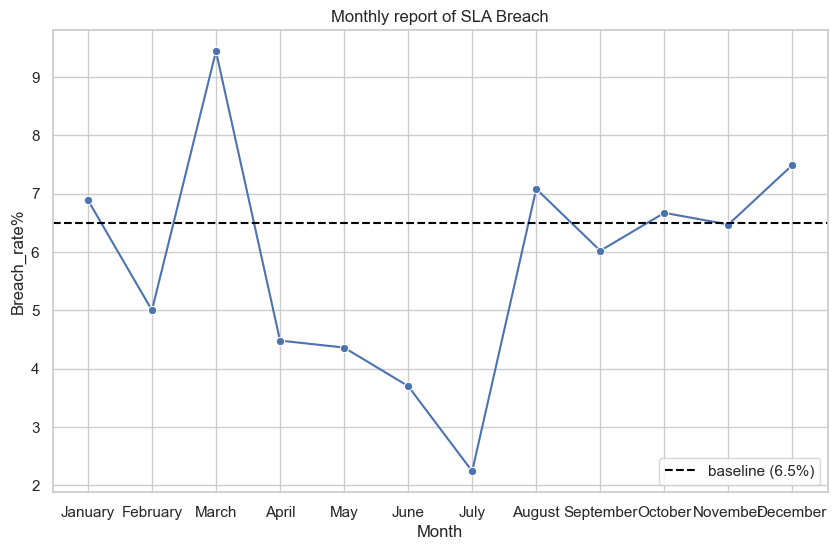

In [31]:
fig,ax=plt.subplots(figsize=(10,6))

sns.lineplot(
    data=visual_opened_at_details_month,
    x='Month',
    y='Breach_rate',
    marker='o',
    ax=ax
)
ax.axhline(y=6.5,linestyle="--",color='black',label='baseline (6.5%)')
plt.title("Monthly report of SLA Breach")
plt.xlabel("Month")
plt.ylabel("Breach_rate%")
plt.legend(loc='lower right')

plt.savefig(
    "../../artifacts/plots/09_month_breach_trend.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Findings

- March exhibits the highest observed SLA breach rate at 9.44%.
- January, August, October, and December also exceed the overall dataset baseline of 6.5%.
- April and May, despite having very high incident volumes, show breach rates below the organizational baseline.
- Several months contain very small numbers of incidents, resulting in less reliable estimates of breach risk.

### Business Interpretation

Month-level analysis was performed to investigate potential seasonal patterns in SLA breach behavior.

Although certain months exhibit higher breach rates than others, the incident distribution across months is highly uneven. The majority of incidents occur during March, April, and May, while several months contain only a small number of observations.

As a result, month-level trends should be interpreted cautiously and are not considered strong evidence of seasonality.

### Modeling Implication

The Month feature may still be retained for experimentation during feature engineering. However, due to the uneven distribution of incidents across months, its predictive value should be validated through feature importance analysis and SHAP explanations before being considered a reliable business driver.

In [32]:
# feature_risk_summary
feature_risk_summary=pd.DataFrame({
    'feature_type':
    [
        'Contact_type',
        'Category',
        'Subcategory',
        'Symptom',
        'Location'
    ],
    'Highest_Risk_Group':
    [
        visual_contact_details.iloc[0]['contact_type'],
        visual_category_details.iloc[0]['category'],
        visual_subcategory_details.iloc[0]['subcategory'],
        visual_u_symptom_details.iloc[0]['u_symptom'],
        visual_location_details.iloc[0]['location'],
    ],
    'Breach_rate':
    [
        visual_contact_details.iloc[0]['Breach_rate'],
        visual_category_details.iloc[0]['Breach_percentage'],
        visual_subcategory_details.iloc[0]['Breach_percentage'],
        visual_u_symptom_details.iloc[0]['Breach_rate'],
        visual_location_details.iloc[0]['Breach_rate'],
    ]
})

feature_risk_summary

,feature_type,Highest_Risk_Group,Breach_rate
0,Contact_type,Email,17.730000
1,Category,Category 45,12.848853
2,Subcategory,Subcategory 220,16.810000
3,Symptom,Symptom 208,10.520000
4,Location,Location 42,8.110000


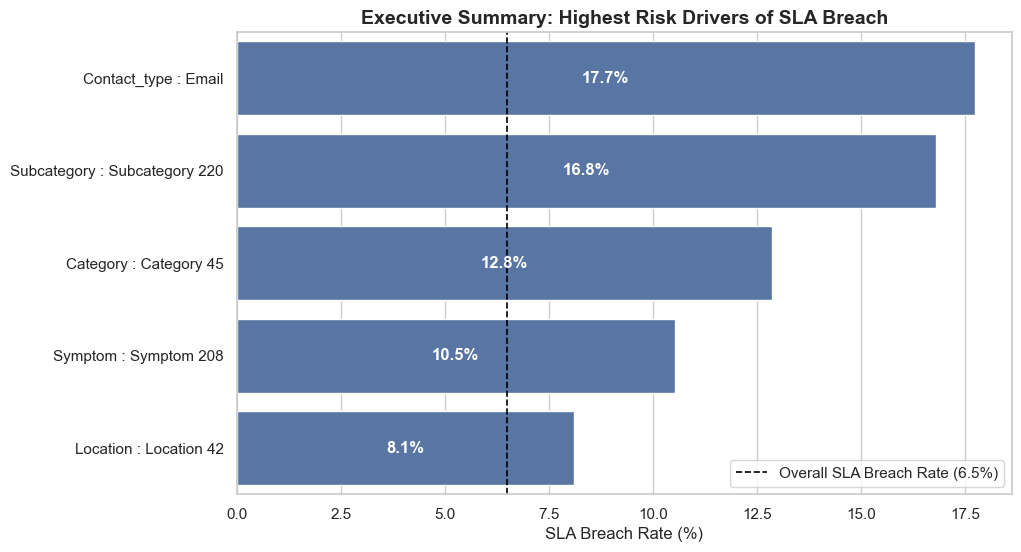

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by breach rate
feature_risk_summary = (
    feature_risk_summary
    .sort_values('Breach_rate', ascending=False)
)

# Create business-friendly labels
feature_risk_summary['Label'] = (
    feature_risk_summary['feature_type']
    + " : "
    + feature_risk_summary['Highest_Risk_Group']
)

# Plot
sns.barplot(
    data=feature_risk_summary,
    x='Breach_rate',
    y='Label',
    ax=ax
)

# Baseline
ax.axvline(
    x=6.5,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Overall SLA Breach Rate (6.5%)'
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        color='white',
        weight='bold'
    )

# Titles and labels
ax.set_xlabel("SLA Breach Rate (%)")
ax.set_ylabel("")
ax.set_title(
    "Executive Summary: Highest Risk Drivers of SLA Breach",
    fontsize=14,
    weight='bold'
)

ax.legend(loc='lower right')

# Save
plt.savefig(
    "../../artifacts/plots/10_feature_risk_summary.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Executive Summary of SLA Breach Risk Drivers

To identify the most important drivers of SLA breaches, the highest-risk group from each major business dimension was compared against the overall breach baseline of 6.5%.

The analysis revealed that incidents reported through the Email channel exhibited the highest breach rate at 17.73%, nearly three times the organizational baseline. At the service classification level, Subcategory 220 showed a breach rate of 16.81%, while Category 45 recorded a breach rate of 12.85%.

From a symptom perspective, Symptom 208 demonstrated elevated operational risk with a breach rate of 10.52%. Location 42 was identified as the highest-risk location, with an SLA breach rate of 8.11%.

These findings indicate that SLA breach risk is not uniformly distributed across incidents. Instead, certain contact channels, service areas, symptoms, and locations consistently exhibit higher-than-average breach behavior. These attributes should be retained as candidate predictive features during feature engineering and model development.
